In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
mdb_df = pd.read_json('jsonbench/results/mongodb/benchmark.json')
cb_df = pd.read_json('jsonbench/results/couchbase/benchmark.json')

In [3]:
# mdb_df = mdb_df[mdb_df["name"] != "Query 8"]
mdb_time_df = mdb_df.groupby(by="name").mean()
mdb_time_df

,time
name,
Query 1,0.002791
Query 2,0.006576
Query 3,0.003497
Query 4,0.001228
Query 5,0.004474
Query 6,0.056793
Query 7,0.017008
Query 8,0.387456


In [4]:
cb_time_df = cb_df.groupby(by="name").mean()
cb_time_df

,time
name,
Query 1,0.000006
Query 2,0.000006
Query 3,0.000007
Query 4,0.000007
Query 5,0.000006
Query 6,0.000007
Query 7,0.000011
Query 8,0.000009


In [5]:
time_df = pd.merge(mdb_time_df, cb_time_df, on="name", how="inner").rename(columns={"name": "name", "time_x": "mongodb", "time_y": "couchbase"})
time_df

,mongodb,couchbase
name,,
Query 1,0.002791,0.000006
Query 2,0.006576,0.000006
Query 3,0.003497,0.000007
Query 4,0.001228,0.000007
Query 5,0.004474,0.000006
Query 6,0.056793,0.000007
Query 7,0.017008,0.000011
Query 8,0.387456,0.000009


<Axes: xlabel='name'>

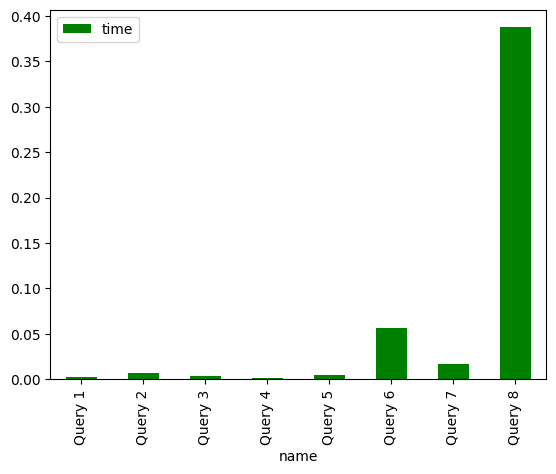

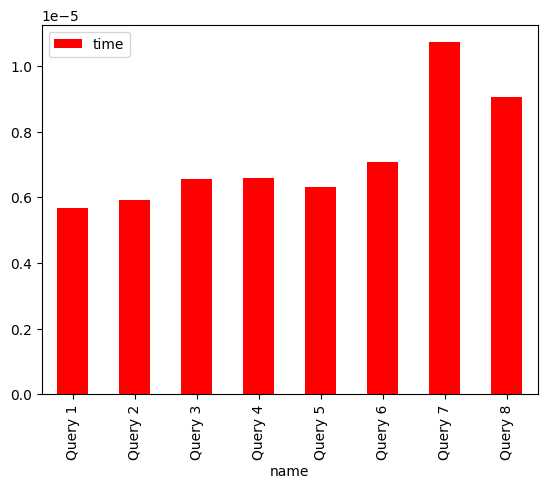

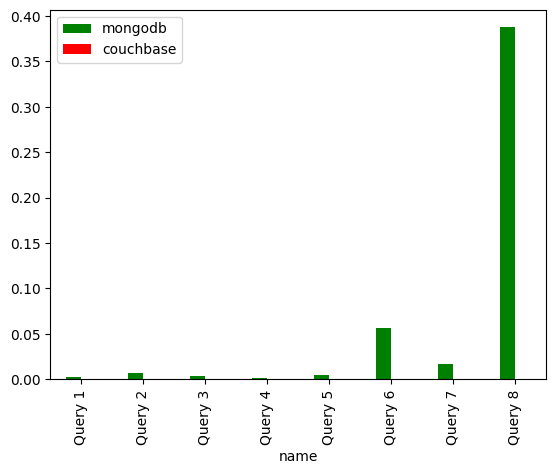

In [6]:
mdb_time_df.plot.bar(color="green")
cb_time_df.plot.bar(color="red")
time_df.plot.bar(color=["green", "red"])

<Axes: >

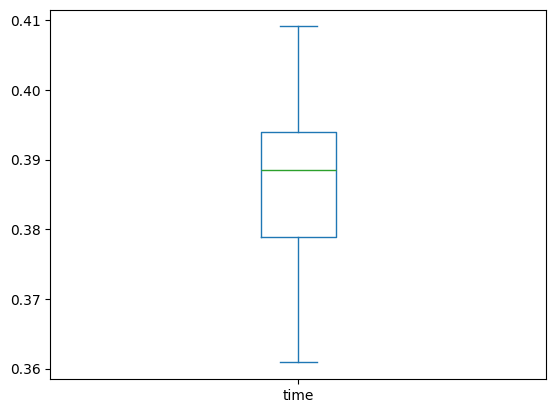

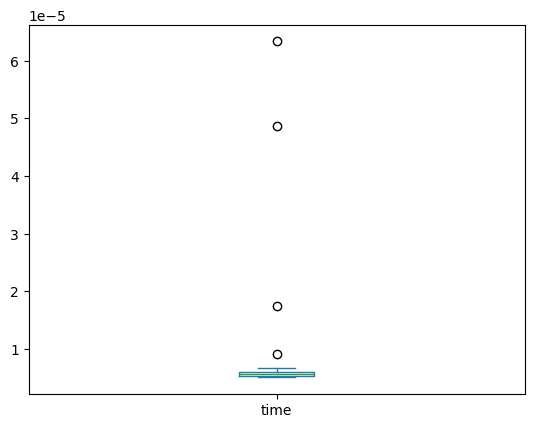

In [7]:
mdb_df[mdb_df['name'] == "Query 8"].plot.box()
cb_df[cb_df['name'] == "Query 8"].plot.box()